In [1]:
# Import the needed libraries
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Import the dataset
data = pd.read_csv(r"C:\Users\ugoch\OneDrive\Desktop\PROJECTS\EXPLORATORY_DATA_ANALYSIS_PROJECTS\BIKE_SALES_DATASET\bike_sales_messy_dataset.csv")


## Remove Duplicate Records

In [2]:
print("Before:")
print(f'Number of Rows/Records: {data.shape[0]}\nNumber of Columns/Variables: {data.shape[1]}')

data = data.drop_duplicates()
print("")
print("After:")
print(f'Number of Rows/Records: {data.shape[0]}\nNumber of Columns/Variables: {data.shape[1]}')

Before:
Number of Rows/Records: 735000
Number of Columns/Variables: 24

After:
Number of Rows/Records: 700000
Number of Columns/Variables: 24


## Extract the Customer Information

In [3]:
# Customer Data columns
customer_data_columns = ['Order ID', 'Date of Purchase', 'Customer Age', 'Gender',
       'Marital Status', 'Income', 'Educational Level', 'Occupation', 'Commute Distance', 
        'Home Ownership', 'Number of Cars','Number of Children', 'Purchased or Not']

# Retrieve Customer Dataset
customer_data = data[customer_data_columns].copy()
customer_data

,Order ID,Date of Purchase,Customer Age,Gender,Marital Status,Income,Educational Level,Occupation,Commute Distance,Home Ownership,Number of Cars,Number of Children,Purchased or Not
0,562534,2021-10-11 16:12:27,30,Non-binary,Married,64720.27171227959,bs,Manager,NaN,unknown,1,2,✔️
1,94346,2024-03-13 18:44:54,42,man,Single,54224.76354784306,ged,unemp,3-5 miles,Own,2,0,✔️
2,37446,2021-04-05 16:36:01,60,FEMALE,Widowed,80926.50371626599,dropout,NaN,walk,Mortgage,3,1,N
3,354279,2025-01-24 23:40:31,50,feMale,D,8929.258846415716,masters,nurse,unknown,other,1,1,Yes
4,515537,2021-02-15 14:55:15,42,unknown,S,62573.43144788382,Bachelor's,Engineer,unknown,NaN,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
734994,235385,2020-06-07 13:41:46,82,F,Married,46571.13715721751,bs,NaN,NaN,Rent,1,1,n
734995,382795,2022-06-01 08:22:46,63,♀,Divorced,66775.1689326152,unknown,Sales,NaN,other,1,0,No
734996,261778,2025-06-24 06:27:56,45,Fémale,Separated,21651.340179919447,elementary,engr,NaN,Rent,1,1,No
734997,306747,2021-07-24 07:18:36,27,m,NaN,60020.492058554926,dropout,teach,train,Rent,1,0,No


## Standardize Column Names

In [4]:
# Standardize the column name formats
customer_data.columns = (customer_data.columns
               .astype(str)
               .str.strip()
               .str.lower()
               .str.replace(" ", "_")
               )

customer_data.columns

Index(['order_id', 'date_of_purchase', 'customer_age', 'gender',
       'marital_status', 'income', 'educational_level', 'occupation',
       'commute_distance', 'home_ownership', 'number_of_cars',
       'number_of_children', 'purchased_or_not'],
      dtype='object')

# Handling Columns

## Date of Purchase

In [5]:
# Contains text values like "yesterday" and "invalid date".
# Goal is to replace them with pd.NaT

mask = (customer_data['date_of_purchase']
       .astype(str)
       .str.contains('yesterday')
       )

mask_1 = (customer_data['date_of_purchase']
       .astype(str)
       .str.contains('invalid date')
       )

check_mask = (mask | mask_1)
customer_data.loc[check_mask, 'date_of_purchase'] = pd.NaT
                                    

# Change the Data Type from String/Object to DateTime.
# Force / Coerce the values where necessary.

customer_data['date_of_purchase'] = pd.to_datetime(customer_data['date_of_purchase'], errors = 'coerce').dt.normalize()
customer_data['date_of_purchase'].head()

0   2021-10-11
1   2024-03-13
2   2021-04-05
3   2025-01-24
4   2021-02-15
Name: date_of_purchase, dtype: datetime64[ns]

# NUMERICAL COLUMNS

In [6]:
# Numerical columns (or Columns that should hold Numerical Data).
numerical_cols = ['customer_age', 'income', 'number_of_cars', 'number_of_children']


# Format any text values appropriately.
for cols in numerical_cols:
    customer_data[cols] = (customer_data[cols]
                     .astype(str)
                     .str.strip()
                     .str.lower()
                    )

## Income

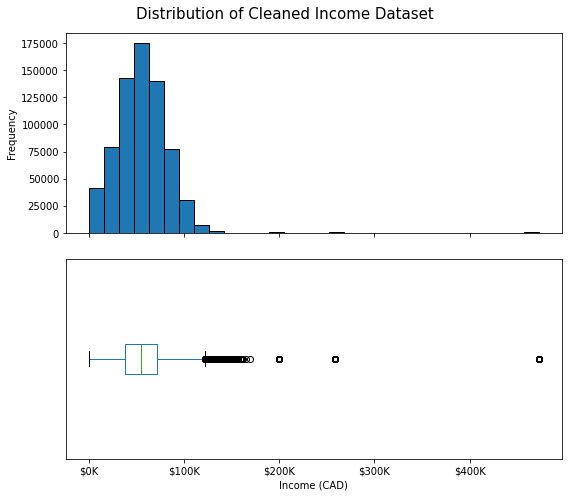

In [7]:
# PRELIMINARY ANALYSIS.
# Goal is the output the original values in descending order
# so as to see the positive outliers present, and the first
# high value that makes sense.

# Get income column
incomes = customer_data['income']

# Convert the values to numeric. Coerce if need be.
incomes = pd.to_numeric(incomes, errors = 'coerce')
incomes = np.round(incomes, 2)
incomes.sort_values(ascending = False).unique()[0:10] 

# Compute needed statistics.
Q1 = incomes.quantile(0.25) # Lower Quartile
Q2 = incomes.quantile(0.5) # Median
Q3 = incomes.quantile(0.75) # Upper Quartile

upper_limit = Q3 + 11.5 * (Q3 - Q1)
# print(upper_limit)


#--------------------
# FROM GOOGLE SEARCH:
#--------------------

# Upper Middle Class: 117,045 to 258,482 CAD per year
# Upper Class / Rich: 258,482 CAD and up per year
# Top 10% Earners: ~111,900+ CAD per year (Median at 147,100)
# Top 1%: Starts at 315,911 with average hitting 586900
# Top 1% Threshold for Manitoba is ~472,900



#1.
## HANDLE OUTLIER VALUE (9999999).

# Replace the outlier value with the Minimum Threshold value
# of the top 1% (club of) earners in Manitoba Canada; 472,900 CAD.

customer_data['income'] = (customer_data['income']
                         .astype(str)
                         .replace('9999999', str(472900))
                         )




#2.
## ENTIRELY TEXT VALUES.

# rich will be taken to be the Upper Class earners in Canada (258,482 CAD annually)
# unknown will be replaced with nan.
# zero will be represented as 0. This will later be replaced with a value (median).

# Replace the text values.
customer_data['income'] = (customer_data['income']
                            .astype(str)
                            .replace('fifty thousand', '50000', regex = True)
                            .replace('zero', '0', regex = True)
                            .replace('unknown', 'nan', regex = True)
                            .replace('rich', '258482', regex = True)
                            )



#2.1.
## MIX OF TEXT AND NUMBERS

# The values include '100k+', '>200k', '45k','$45,000'

# Replace the values.
customer_data['income'] = (customer_data['income']
                            .astype(str)
                            .replace(r'[+$>,]', '', regex = True)
                            .replace('k', '000', regex = True)
                            )



#3
## HANDLING NEGATIVE VALUES.

# Values of -1, -10000
mask = (pd.to_numeric(customer_data['income'], errors = 'coerce') < 0)
# mask1 = (pd.to_numeric(customer_data['income'], errors = 'coerce') == 0)

check_mask = mask

# Handle this as missing values.
# Values of 0, -1 and -10000 can be seen as dummy data.

customer_data.loc[check_mask, 'income'] = np.nan



#4.
## HANDLING MISSING DATA.

# Get income column
income_data = customer_data['income']

# Convert the values to numeric. Coerce if need be.
income_data = pd.to_numeric(income_data, errors = 'coerce')

# Compute needed statistics.
Q1 = income_data.quantile(0.25) # Lower Quartile
Q2 = income_data.quantile(0.5) # Median
Q3 = income_data.quantile(0.75) # Upper Quartile


# Replace the missing values with the median value
customer_data['income']= (customer_data['income']
                               .astype(str)
                               .replace('nan', str(Q2))
                               )



#5.

# From further analysis, results of checks performed on
# income values less than 21520 gave result ranging
# from 7.3 to 21519.6. Values less than the LICO (Low Income Cut-Off)
# in Manitoba (21522) for rural areas.
# Correcting this value to the accepted LICO value WILL NOT ALTER
# THE INCOME CLASS OF THE CUSTOMER but will make the data rational.
# The correction was done on income values less than or equal to 10000.

# **N/B**: 
## INCOME CAN BE ZERO. THUS VALUES CAN BE LESS THAN LICO.


#6.
# Change data type of column.
customer_data['income'] = pd.to_numeric(customer_data['income'], errors = 'coerce')


#7.
# Correcting values less than LICO
# mask = (pd.to_numeric(customer_data['income'], errors = 'coerce') <= 21522)
# customer_data.loc[mask, 'income'] = 21522


#8.
# Setting the decimal places to 2.
customer_data['income'] = np.round(customer_data['income'], 2)



#9.
# DISTRIBUTION OF DATA POINTS.
fig, ax = plt.subplots(2, 1, figsize = (8,7))
customer_data['income'].plot(kind = 'hist', bins = 30, edgecolor = 'black', ax = ax[0])
ax[0].set_xticklabels('')
# ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))

customer_data['income'].plot(kind = 'box', vert = False, ax = ax[1])
ax[1].set_xlabel("Income (CAD)")
ax[1].set_ylabel('')
ax[1].set_yticks([])
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))

fig.suptitle('Distribution of Cleaned Income Dataset', fontsize = 15)
plt.tight_layout(h_pad = 2);



## Customer Age

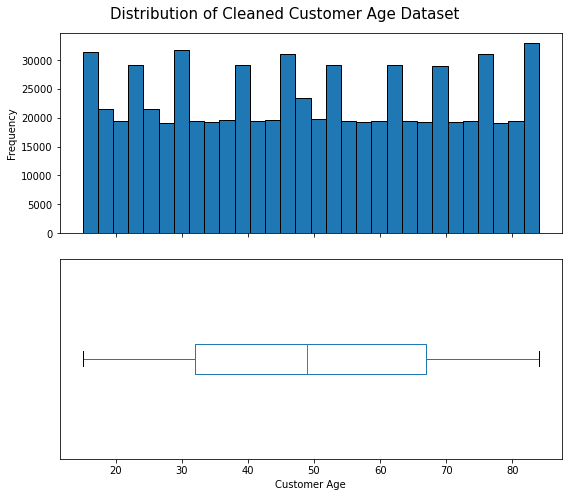

In [8]:
# PRELIMINARY ANALYSIS.
# Goal is the output the original values in descending order
# so as to see the positive outliers present. The same is done
# in reverse order to see negative outliers present.

# Get income column
age_data = customer_data['customer_age']

# Convert the values to numeric. Coerce if need be.
age_data = pd.to_numeric(age_data, errors = 'coerce')
age_data = np.round(age_data, 2)
# print(age_data.sort_values(ascending = False).unique()[0:10])
# print(age_data.sort_values(ascending = True).unique()[0:10])



#1.
## HANDLE OUTLIER VALUES (999, 150).

# Replace the outlier values with the 99th percentile value
# age dataset assumming that they represent Senior Age values.

# Compute needed statistics.
Q99 = age_data.quantile(0.99) # 99th percentile; Greater than 99% of the values.


# Replacing the Outliers
customer_data['customer_age'] = (customer_data['customer_age']
                         .astype(str)
                         .str.replace(str(999), str(Q99))
                         .str.replace(str(150), str(Q99))
                         )


#2.
## ENTIRELY TEXT VALUES.
# 'thirty', 'old','forty-five', 'unknown'

# old will be replaced by the median value of ages from 65 to 99th percentile
# which is the age range from old.
# unknown will be replaced with nan.
# thirty and forty-five zero will be represented by their number equivaluents.

# Replace the text values.
customer_data['customer_age'] = (customer_data['customer_age']
                            .astype(str)
                            .replace('thirty', '30', regex = True)
                            .replace('forty-five', '45', regex = True)
                            .replace('unknown', 'nan', regex = True)
                            )



# Handling the 'old' vtext value.
age_column = customer_data['customer_age'].copy()
age_column = pd.to_numeric(age_column, errors = 'coerce')
old_age = age_column[age_column.between(65, Q99)]
median_old_age = np.round(old_age.median(),0)



# Replace 'old' with the median value of old age
customer_data['customer_age'] = (customer_data['customer_age']
                                .astype(str)
                                .str.replace('old', str(median_old_age), regex = True)
                                )



#2.1.
## MIX OF TEXT AND NUMBERS
# '18 years', '25+' 

# Replace the non-numeric characters.
customer_data['customer_age'] = (customer_data['customer_age']
                                           .astype(str)
                                           .str.replace('+', '', regex = True)
                                           .str.replace(' years', '', regex = True)
                                          )


#3
## HANDLING NEGATIVE VALUES.
# -5

mask = (pd.to_numeric(customer_data['customer_age'], errors = 'coerce') < 0)

# Handle this as dummy data outside the lowest range.
# Value of -5 be taken as dummy data.

# Replace it with the 1th percentile value.
customer_data.loc[mask, 'customer_age'] = pd.to_numeric(customer_data['customer_age'], errors = 'coerce').quantile(0.01)



#4.
## HANDLING MISSING DATA.

# Get income column
age_data = customer_data['customer_age']

# Convert the values to numeric. Coerce if need be.
age_data = pd.to_numeric(age_data, errors = 'coerce')

# Compute needed statistics.
Q1 = age_data.quantile(0.25) # Lower Quartile
Q2 = age_data.quantile(0.5) # Median
Q3 = age_data.quantile(0.75) # Upper Quartile


# Replace the missing values with the median value
customer_data['customer_age']= (customer_data['customer_age']
                               .astype(str)
                               .replace('nan', str(Q2))
                               )




#5.
# Change data type of column.
customer_data['customer_age'] = pd.to_numeric(customer_data['customer_age'], errors = 'coerce')



#6.
# Setting the decimal places to 2.
customer_data['customer_age'] = np.round(customer_data['customer_age'], 2)


# print(age_data.sort_values(ascending = True).unique()[0:10])


#7.
# DISTRIBUTION OF DATA POINTS.
fig, ax = plt.subplots(2, 1, figsize = (8,7))
customer_data['customer_age'].plot(kind = 'hist', bins = 30, edgecolor = 'black', ax = ax[0])
ax[0].set_xticklabels('')
# ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))

customer_data['customer_age'].plot(kind = 'box', vert = False, ax = ax[1])
ax[1].set_xlabel("Customer Age")
ax[1].set_ylabel('')
ax[1].set_yticks([])
# ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))

fig.suptitle('Distribution of Cleaned Customer Age Dataset', fontsize = 15)
plt.tight_layout(h_pad = 2);


## Number of Cars

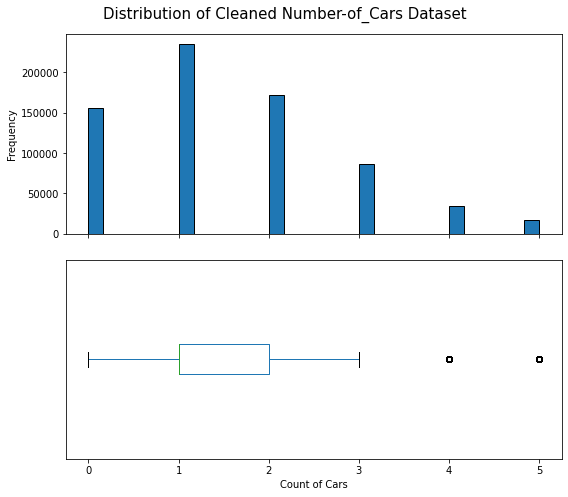

In [9]:
# PRELIMINARY ANALYSIS.
# Goal is the output the original values in descending order
# so as to see the positive outliers present. The same is done
# in reverse order to see the negative outliers present (if any).

# Get income column
cars_data = customer_data['number_of_cars']

# Convert the values to numeric. Coerce if need be.
cars_data = pd.to_numeric(cars_data, errors = 'coerce')
cars_data = np.round(cars_data, 2)

# print(cars_data.sort_values(ascending = False).unique()[0:10])
# print(cars_data.sort_values(ascending = True).unique()[0:10])
# print(cars_data.quantile(0.99))


#1.
## HANDLE OUTLIER VALUES (99).

# Replace the outlier values with the 99th percentile value
# of cars dataset assumming that the outlier represents a high value.

# Compute needed statistics.
Q99 = cars_data.quantile(0.99) # 99th percentile; Greater than 99% of the values.


# Replacing the Outliers
customer_data['number_of_cars'] = (customer_data['number_of_cars']
                         .astype(str)
                         .str.replace(str(99), str(Q99))
                         )


#2.
## ENTIRELY TEXT VALUES.
# 'none', 'many', 'unknown', and 'several'

# 1-2 cars: Usually referred to as a "few" or a "couple"
# 3-4 cars: Commonly accepted as "several" in general or practical terms
# 5 or more cars: Often translates to "many" or a "fleet"

# Replace the text values.
customer_data['number_of_cars'] = (customer_data['number_of_cars']
                            .astype(str)
                            .replace('many', '5', regex = True)
                            .replace('several', '4', regex = True)
                            .replace('unknown', 'nan', regex = True)
                            .replace('none', '0', regex = True)
                        )



#3
## HANDLING NEGATIVE VALUES.
# -1

mask = (pd.to_numeric(customer_data['number_of_cars'], errors = 'coerce') < 0)

# Handle this as missing values.
# Value of -1 be seen as dummy data.

customer_data.loc[mask, 'number_of_cars'] = np.nan




#4.
## HANDLING MISSING DATA.

# Get income column
cars_data = customer_data['number_of_cars']

# Convert the values to numeric. Coerce if need be.
cars_data = pd.to_numeric(cars_data, errors = 'coerce')

# Compute needed statistics.
Q1 = cars_data.quantile(0.25) # Lower Quartile
Q2 = cars_data.quantile(0.5) # Median
Q3 = cars_data.quantile(0.75) # Upper Quartile


# Replace the missing values with the median value
customer_data['number_of_cars']= (customer_data['number_of_cars']
                               .astype(str)
                               .replace('nan', str(Q2))
                               )




#5.
# Change data type of column.
customer_data['number_of_cars'] = pd.to_numeric(customer_data['number_of_cars'], errors = 'coerce')



#6.
# Setting the decimal places to 2.
customer_data['number_of_cars'] = np.round(customer_data['number_of_cars'], 2)



#7.
# DISTRIBUTION OF DATA POINTS.
fig, ax = plt.subplots(2, 1, figsize = (8,7))
customer_data['number_of_cars'].plot(kind = 'hist', bins = 30, edgecolor = 'black', ax = ax[0])
ax[0].set_xticklabels('')
# ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))

customer_data['number_of_cars'].plot(kind = 'box', vert = False, ax = ax[1])
ax[1].set_xlabel("Count of Cars")
ax[1].set_ylabel('')
ax[1].set_yticks([])
# ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))

fig.suptitle('Distribution of Cleaned Number-of_Cars Dataset', fontsize = 15)
plt.tight_layout(h_pad = 2);

## Number of Children

[50.  6.  5.  4.  3.  2.  1.  0. -5. nan]
[-5.  0.  1.  2.  3.  4.  5.  6. 50. nan]
6.0


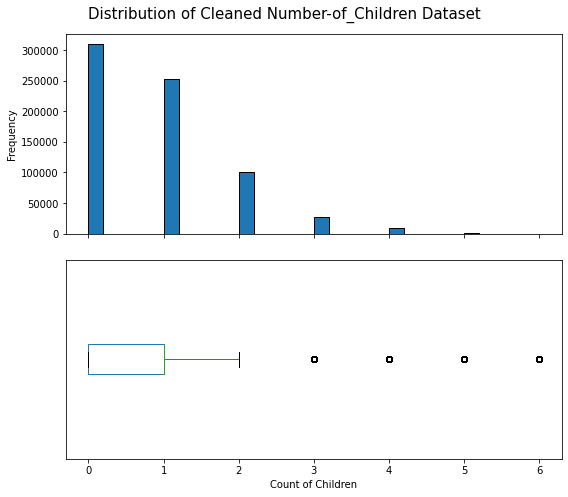

In [10]:
# PRELIMINARY ANALYSIS.
# Goal is the output the original values in descending order
# so as to see the positive outliers present. The same is done
# in reverse order to see the negative outliers present (if any).

# Get income column
children_data = customer_data['number_of_children']

# Convert the values to numeric. Coerce if need be.
children_data = pd.to_numeric(children_data, errors = 'coerce')
children_data = np.round(children_data, 2)

print(children_data.sort_values(ascending = False).unique()[0:10])
print(children_data.sort_values(ascending = True).unique()[0:10])
print(children_data.quantile(0.9971))




#1.
## HANDLE OUTLIER VALUES (50).

# Replace the outlier values with the 99th percentile value
# of children dataset assumming that the outlier represents a high value.

# Compute needed statistics.
Q99 = children_data.quantile(0.99) # 99th percentile; Greater than 99% of the values.


# Replacing the Outliers
customer_data['number_of_children'] = (customer_data['number_of_children']
                         .astype(str)
                         .str.replace(str(50), str(Q99))
                         )


#2.
## ENTIRELY TEXT VALUES.
# 'many', 'twins', 'unknown', and 'none'.

# Linguistically and Culturally, the minimum number 
# that represents "many" children is generally 4.
# Google search engine. . . . 5th July 2026.
# However, this will be replaced with the 99th percentile 
# value as 'many' also be in the magnitude of the positive outlier.

# Replace the text values.
customer_data['number_of_children'] = (customer_data['number_of_children']
                            .astype(str)
                            .replace('many', '4', regex = True)
                            .replace('twins', '2', regex = True)
                            .replace('unknown', 'nan', regex = True)
                            .replace('none', '0', regex = True)
                            )



#3
## HANDLING NEGATIVE VALUES.
# -1

mask = (pd.to_numeric(customer_data['number_of_children'], errors = 'coerce') < 0)

# Handle this as missing values.
# Value of -1 be seen as dummy data.

customer_data.loc[mask, 'number_of_children'] = np.nan




#4.
## HANDLING MISSING DATA.

# Get income column
children_data = customer_data['number_of_children']

# Convert the values to numeric. Coerce if need be.
children_data = pd.to_numeric(children_data, errors = 'coerce')

# Compute needed statistics.
Q1 = children_data.quantile(0.25) # Lower Quartile
Q2 = children_data.quantile(0.5) # Median
Q3 = children_data.quantile(0.75) # Upper Quartile


# Replace the missing values with the median value
customer_data['number_of_children']= (customer_data['number_of_children']
                               .astype(str)
                               .replace('nan', str(Q2))
                               )



#5.
# Change data type of column.
customer_data['number_of_children'] = pd.to_numeric(customer_data['number_of_children'], errors = 'coerce')



#6.
# Setting the decimal places to 2.
customer_data['number_of_children'] = np.round(customer_data['number_of_children'], 2)



#7.
# DISTRIBUTION OF DATA POINTS.
fig, ax = plt.subplots(2, 1, figsize = (8,7))
customer_data['number_of_children'].plot(kind = 'hist', bins = 30, edgecolor = 'black', ax = ax[0])
ax[0].set_xticklabels('')

customer_data['number_of_children'].plot(kind = 'box', vert = False, ax = ax[1])
ax[1].set_xlabel("Count of Children")
ax[1].set_ylabel('')
ax[1].set_yticks([])

fig.suptitle('Distribution of Cleaned Number-of_Children Dataset', fontsize = 15)
plt.tight_layout(h_pad = 2);

# CATEGORICAL COLUMNS

In [11]:
categorical_cols = ['gender','marital_status', 'educational_level', 'occupation',
                    'commute_distance', 'home_ownership', 'purchased_or_not']

# Since the columns are ALL Categorical, the missing values 
# in them will be replaced by 'Unknown'.

# Also, AND THIS VERY IMPORTANT, a title case will be applied
# to their entries. This MAY end up REDUCING THE NUMBER OF
# UNIQUE ENTRIES IN EACH COLUMN as was seen during the Exploratory
# Data Analysis.


# Fill the missing data with 'Unknown'
customer_data[categorical_cols] = customer_data[categorical_cols].fillna("Unknown")


# Ensure consistency of capitalization. Apply Title case to values.
for cols in categorical_cols:
    customer_data[cols] = (customer_data[cols]
                                 .astype(str)
                                 .str.strip()
                                 .str.title()
                    )

## Gender

Number of Unique Entries (After Capitalization): 16 


Before Mapping:
['Non-Binary' 'Man' 'Female' 'Unknown' '♀' 'F' '♂' 'Mail' 'She/Her' 'M'
 'Prefer Not To Say' 'Woman' 'He/Him' 'Mâle' 'Male' 'Fémale'] 


After Mapping:
['Non-Binary' 'Male' 'Female' 'Unknown' 'Unspecified'] 

Female         287244
Male           285426
Unknown         63730
Non-Binary      31964
Unspecified     31636
Name: gender, dtype: int64 



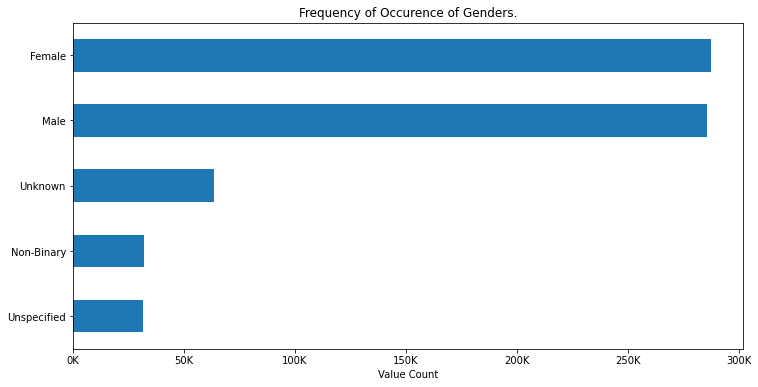

In [12]:
# Check the number of unique entries
print("Number of Unique Entries (After Capitalization):",customer_data['gender'].nunique(), "\n")
# Unique values reduced from 21 to 16.


# Show the current unique values.
print("\nBefore Mapping:")
print(customer_data['gender'].unique(), "\n")


# Create a mapping
mapping_gender = {'Man' : 'Male', '♂' : 'Male', 'Mail' : 'Male', 'M' : 'Male', 'He/Him' : 'Male', 'Mâle' : 'Male',
                  '♀' : 'Female', 'F' : 'Female', 'She/Her' : 'Female', 'Woman' : 'Female', 'Fémale' : 'Female',
                  'Prefer Not To Say' : 'Unspecified'}


# Apply the mapping
customer_data['gender'] = customer_data['gender'].map(mapping_gender).fillna(customer_data['gender'])
      
    
# Show the current unique values.
print("\nAfter Mapping:")
print(customer_data['gender'].unique(), "\n")


# Frequency of occurence of each value
print(customer_data['gender'].value_counts(), "\n")

plt.figure(figsize= (12,6))
customer_data['gender'].value_counts(ascending = True).plot(kind = 'barh')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x/1000)}K'))
plt.ylabel('')
plt.xlabel('Value Count')
plt.title('Frequency of Occurence of Genders.')
plt.show()

## Marital Status

Number of Unique Entries (After Capitalization): 12 


Before Mapping:
['Married' 'Single' 'Widowed' 'D' 'S' 'Unknown' 'Living Together'
 'Complicated' 'W' 'Separated' 'M' 'Divorced'] 


After Mapping:
['Married' 'Single' 'Widowed' 'Divorced' 'Unknown' 'Partnership'
 'Complicated' 'Separated'] 

Married        155828
Single         155222
Unknown        116803
Divorced        78079
Widowed         77741
Separated       38971
Partnership     38789
Complicated     38567
Name: marital_status, dtype: int64 



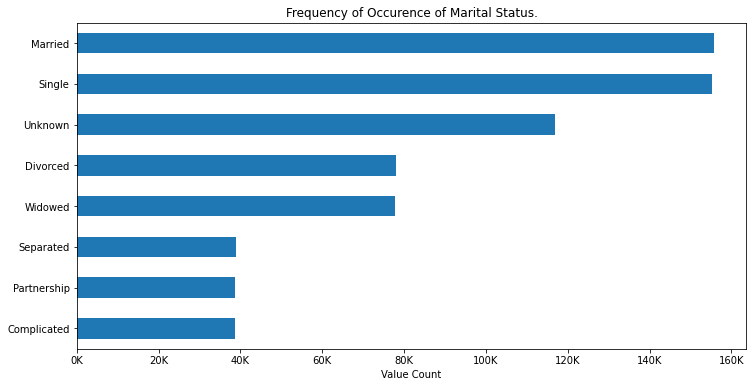

In [13]:
# Check the number of unique entries
print("Number of Unique Entries (After Capitalization):",customer_data['marital_status'].nunique(), "\n")
# Unique values reduced from 16 to 12.


# Show the current unique values.
print("\nBefore Mapping:")
print(customer_data['marital_status'].unique(), "\n")


# Create a mapping
mapping_marital = {'D' : 'Divorced', 'S' : 'Single', 'Living Together' : 'Partnership',
                    'W' : 'Widowed', 'M' : 'Married'}


# Apply the mapping
customer_data['marital_status'] = customer_data['marital_status'].map(mapping_marital).fillna(customer_data['marital_status'])
      
# Show the current unique values.
print("\nAfter Mapping:")
print(customer_data['marital_status'].unique(), "\n")


# Frequency of occurence of each value
print(customer_data['marital_status'].value_counts(), "\n")

plt.figure(figsize= (12,6))
customer_data['marital_status'].value_counts(ascending = True).plot(kind = 'barh')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x/1000)}K'))
plt.ylabel('')
plt.xlabel('Value Count')
plt.title('Frequency of Occurence of Marital Status.')
plt.show()

## Educational Level

Number of Unique Entries (After Capitalization): 20 


Before Mapping:
['Bs' 'Ged' 'Dropout' 'Masters' "Bachelor'S" 'Doctorate' 'Ba' 'Bachelors'
 "Master'S" 'Ma' 'Elementary' 'High School' 'Unknown' 'Ms' 'Phd'
 'Highschool' 'Hs' 'Some College' 'Associate' 'None'] 


After Mapping:
['Bachelors' 'GED' 'School Leaver' 'Masters' 'Doctorate' 'Elementary'
 'High School' 'Unknown' 'College' 'Associate' 'None'] 

Bachelors        126822
Masters          126782
Doctorate         95776
High School       95673
Unknown           64068
None              32082
College           31880
Associate         31856
School Leaver     31832
Elementary        31793
GED               31436
Name: educational_level, dtype: int64 



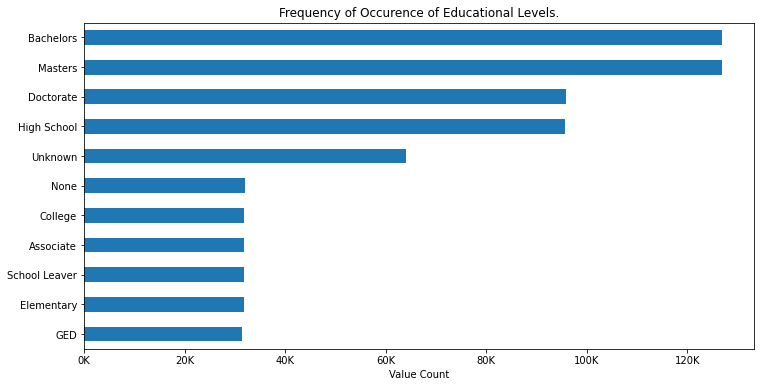

In [14]:
# Check the number of unique entries
print("Number of Unique Entries (After Capitalization):",customer_data['educational_level'].nunique(), "\n")
# Unique values reduced from 21 to 20.


# Show the current unique values.
print("\nBefore Mapping:")
print(customer_data['educational_level'].unique(), "\n")


# Create a mapping
mapping_education = {'Bs' : 'Bachelors', "Bachelor'S" : 'Bachelors', 'Ba' : 'Bachelors',
                        'PhD' : 'Doctorate', 'Dropout' : 'School Leaver', 'Ged' : 'GED',
                        'Highschool' : 'High School', 'Hs' : 'High School' ,
                        "Master'S" : 'Masters', 'Ma' : 'Masters', 'Ms' : 'Masters' ,
                        'Phd' : 'Doctorate', 'Some College' : 'College'}


# Apply the mapping
customer_data['educational_level'] = customer_data['educational_level'].map(mapping_education).fillna(customer_data['educational_level'])
      
# Show the current unique values.
print("\nAfter Mapping:")
print(customer_data['educational_level'].unique(), "\n")


# Frequency of occurence of each value
print(customer_data['educational_level'].value_counts(), "\n")

plt.figure(figsize= (12,6))
customer_data['educational_level'].value_counts(ascending = True).plot(kind = 'barh')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x/1000)}K'))
plt.ylabel('')
plt.xlabel('Value Count')
plt.title('Frequency of Occurence of Educational Levels.')
plt.show()

# Occupation

Number of Unique Entries (After Capitalization): 23 


Before Mapping:
['Manager' 'Unemp' 'Unknown' 'Nurse' 'Engineer' 'Artist' 'Ret' 'Other'
 'Student' 'Retired' 'Freelancer' 'Doctor' 'Teacher' 'Sales' 'Stud'
 'Unemployed' 'Writer' 'Doc' 'Coder' 'Lawyer' 'Homemaker' 'Engr' 'Teach'] 


After Mapping:
['Manager' 'Unemployed' 'Unknown' 'Nurse' 'Engineer' 'Artist' 'Retired'
 'Unspecified' 'Student' 'Freelancer' 'Doctor' 'Teacher' 'Sales' 'Writer'
 'Coder' 'Lawyer' 'Homemaker'] 

Teacher        58748
Student        58356
Doctor         58338
Unknown        58277
Unemployed     58237
Retired        58226
Engineer       57843
Nurse          29419
Artist         29357
Sales          29221
Manager        29187
Coder          29176
Unspecified    29161
Freelancer     29159
Writer         29150
Homemaker      29093
Lawyer         29052
Name: occupation, dtype: int64 



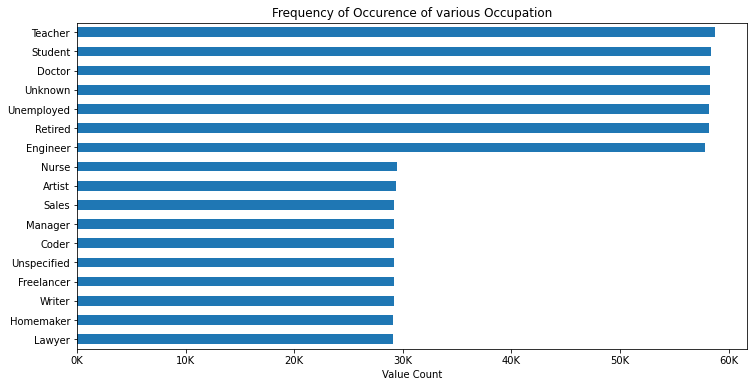

In [15]:
# Check the number of unique entries
print("Number of Unique Entries (After Capitalization):",customer_data['occupation'].nunique(), "\n")
# Unique values remained the samee at 23.


# Show the current unique values.
print("\nBefore Mapping:")
print(customer_data['occupation'].unique(), "\n")


# Create a mapping
mapping_occupation = { 'Unemp':'Unemployed', 'Ret':'Retired', 'Stud':'Student',  
                        'Doc':'Doctor', 'Engr':'Engineer', 'Teach':'Teacher',
                        'Other' : 'Unspecified' 
                     }



# Apply the mapping
customer_data['occupation'] = customer_data['occupation'].map(mapping_occupation).fillna(customer_data['occupation'])
      
# Show the current unique values.
print("\nAfter Mapping:")
print(customer_data['occupation'].unique(), "\n")


# Frequency of occurence of each value
print(customer_data['occupation'].value_counts(), "\n")

plt.figure(figsize= (12,6))
customer_data['occupation'].value_counts(ascending = True).plot(kind = 'barh')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x/1000)}K'))
plt.ylabel('')
plt.xlabel('Value Count')
plt.title('Frequency of Occurence of various Occupation')
plt.show()

## Home Ownership

Number of Unique Entries (After Capitalization): 6 


Before Mapping:
['Unknown' 'Own' 'Mortgage' 'Other' 'Rent' 'Living With Parents'] 


After Mapping:
['Unknown' 'Homeowner/Freeholder' 'Mortgage' 'Other' 'Tenant'
 'Co-Resident'] 

Homeowner/Freeholder    175161
Tenant                  174916
Mortgage                116874
Unknown                 116413
Other                    58415
Co-Resident              58221
Name: home_ownership, dtype: int64 



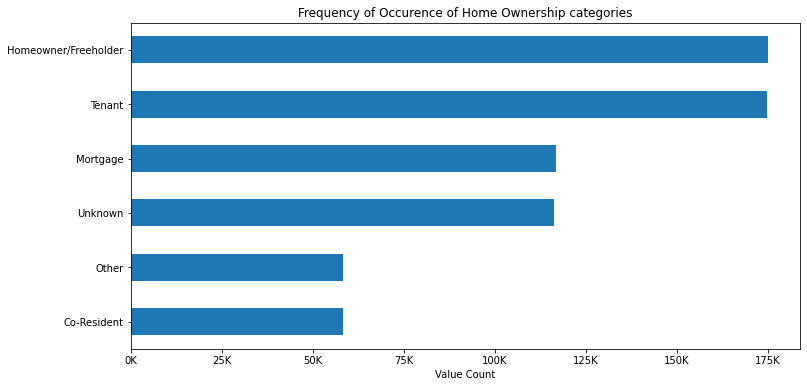

In [16]:
# Check the number of unique entries
print("Number of Unique Entries (After Capitalization):",customer_data['home_ownership'].nunique(), "\n")
# Unique values reduced in number from from 11 to 6.


# Show the current unique values.
print("\nBefore Mapping:")
print(customer_data['home_ownership'].unique(), "\n")


# Create the mappings
mapping_home_ownership = {'Own':'Homeowner/Freeholder',   'Rent':'Tenant',   'Living With Parents':'Co-Resident'}


# Apply the mapping
customer_data['home_ownership'] = customer_data['home_ownership'].map(mapping_home_ownership).fillna(customer_data['home_ownership'])
      
# Show the current unique values.
print("\nAfter Mapping:")
print(customer_data['home_ownership'].unique(), "\n")


# Frequency of occurence of each value
print(customer_data['home_ownership'].value_counts(), "\n")

plt.figure(figsize= (12,6))
customer_data['home_ownership'].value_counts(ascending = True).plot(kind = 'barh')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x/1000)}K'))
plt.ylabel('')
plt.xlabel('Value Count')
plt.title('Frequency of Occurence of Home Ownership categories')
plt.show()


## Commute Distance

Number of Unique Entries (After Capitalization): 11 


Before Mapping:
['Unknown' '3-5 Miles' 'Walk' '1-2 Miles' '<1 Mile' 'Bike' 'Car' 'Train'
 '0' '5-10 Miles' '10+ Miles'] 


After Mapping:
['Unknown' '3-5 Miles' 'Unspecified' '1-2 Miles' '<1 Mile' '5-10 Miles'
 '10+ Miles'] 

Unspecified    215873
Unknown        161479
<1 Mile        108025
1-2 Miles       53822
3-5 Miles       53809
10+ Miles       53615
5-10 Miles      53377
Name: commute_distance, dtype: int64 



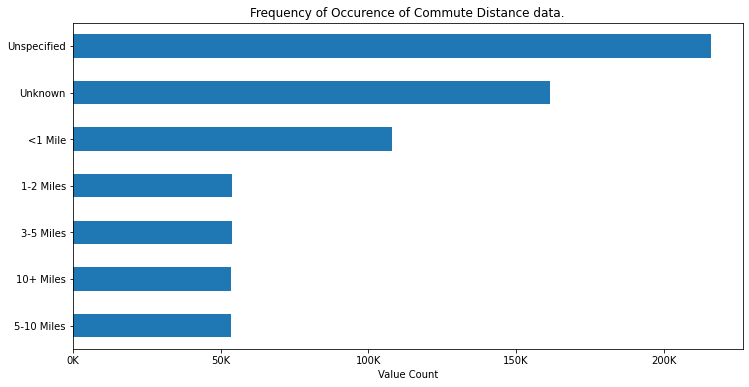

In [17]:
# Check the number of unique entries
print("Number of Unique Entries (After Capitalization):",customer_data['commute_distance'].nunique(), "\n")
# Unique values remained the samee at 11.


# Show the current unique values.
print("\nBefore Mapping:")
print(customer_data['commute_distance'].unique(), "\n")


# Create the mappings
mapping_commute_distance = {'Walk':'Unspecified', 'Bike':'Unspecified', 'Car':'Unspecified',
                                'Train':'Unspecified', '0':'<1 Mile'
                           }


# Apply the mapping
customer_data['commute_distance'] = customer_data['commute_distance'].map(mapping_commute_distance).fillna(customer_data['commute_distance'])
      
# Show the current unique values.
print("\nAfter Mapping:")
print(customer_data['commute_distance'].unique(), "\n")


# Frequency of occurence of each value
print(customer_data['commute_distance'].value_counts(), "\n")

plt.figure(figsize= (12,6))
customer_data['commute_distance'].value_counts(ascending = True).plot(kind = 'barh')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x/1000)}K'))
plt.ylabel('')
plt.xlabel('Value Count')
plt.title('Frequency of Occurence of Commute Distance data.')
plt.show()

## Purchased or Not

Number of Unique Entries (After Capitalization): 18 


Before Mapping:
['✔️' 'N' 'Yes' 'No' 'Y' 'Bought' 'Unknown' 'True' '❌' '1' 'Purchased'
 'Not Purchased' '0' 'False' '✖️' '✅' 'Did Not Buy' 'Maybe'] 


After Mapping:
['Yes' 'No' 'Unknown' 'Unspecified'] 

Yes            349599
No             329445
Unknown         13986
Unspecified      6970
Name: purchased_or_not, dtype: int64 



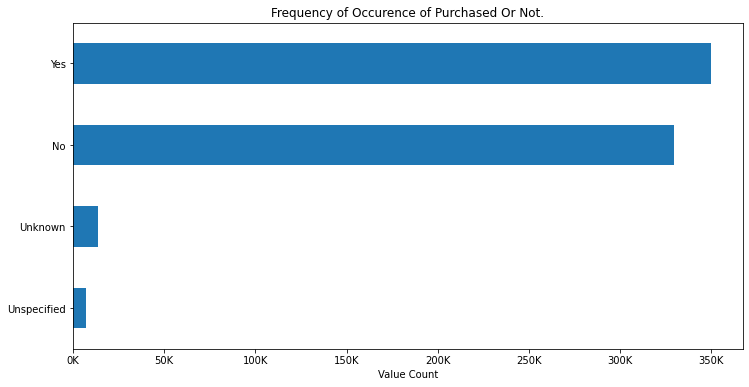

In [18]:
# Check the number of unique entries
print("Number of Unique Entries (After Capitalization):",customer_data['purchased_or_not'].nunique(), "\n")
# Unique values reduced from 28 to 18.


# Show the current unique values.
print("\nBefore Mapping:")
print(customer_data['purchased_or_not'].unique(), "\n")


# Create the mapping
mapping_purchased = { '✔️':'Yes',   'Y':'Yes',   'Bought':'Yes',   'True':'Yes',   '1':'Yes',   'Purchased':'Yes',   '✅':'Yes',
                      'N':'No',   '❌':'No',   'Not Purchased':'No' ,   'False':'No',   '✖️':'No',   'Did Not Buy':'No',   '0':'No',
                      'Maybe':'Unspecified'
                    }

# Apply the mapping
customer_data['purchased_or_not'] = customer_data['purchased_or_not'].map(mapping_purchased).fillna(customer_data['purchased_or_not'])
      
# Show the current unique values.
print("\nAfter Mapping:")
print(customer_data['purchased_or_not'].unique(), "\n")


# Frequency of occurence of each value
print(customer_data['purchased_or_not'].value_counts(), "\n")

plt.figure(figsize= (12,6))
customer_data['purchased_or_not'].value_counts(ascending = True).plot(kind = 'barh')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x/1000)}K'))
plt.ylabel('')
plt.xlabel('Value Count')
plt.title('Frequency of Occurence of Purchased Or Not.')
plt.show()

In [19]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 700000 entries, 0 to 734998
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            700000 non-null  int64         
 1   date_of_purchase    692822 non-null  datetime64[ns]
 2   customer_age        700000 non-null  float64       
 3   gender              700000 non-null  object        
 4   marital_status      700000 non-null  object        
 5   income              700000 non-null  float64       
 6   educational_level   700000 non-null  object        
 7   occupation          700000 non-null  object        
 8   commute_distance    700000 non-null  object        
 9   home_ownership      700000 non-null  object        
 10  number_of_cars      700000 non-null  float64       
 11  number_of_children  700000 non-null  float64       
 12  purchased_or_not    700000 non-null  object        
dtypes: datetime64[ns](1), float64

## Create Documents

In [20]:
# Create a file containing the final cleaned dataset
customer_data.to_csv('cleaned_customer_data.csv')

### Create Data and Dimension tables for a Database.

#### Gender

In [21]:
gender_values = customer_data['gender'].copy()
gender_values.unique()

# Convert gender series to dataframe
df_gender = pd.DataFrame(gender_values)

# Create a function to handle id column entries
def create_gender_id(value):
    if value == "Non-Binary":
        return "Non-BI"
    
    elif value == "Male":
        return "M"
    
    elif value == "Female":
        return "F"
    
    elif value == "Unknown":
        return "UNK"
    
    elif value == "Unspecified":
        return "UNS"
    
    else:
        return value
    
# Create the primary key column
df_gender['gender_id'] = df_gender["gender"].apply(create_gender_id)
df_gender = df_gender.drop_duplicates()
df_gender = df_gender.set_index('gender_id')
df_gender = df_gender.reset_index()
df_gender # Put in a print function to see the output

# Save it to a file
df_gender.to_csv("genders.csv")

#### Marital Status

In [22]:
marital_status_values = customer_data['marital_status'].copy()
marital_status_values.unique()

# Convert marital series to dataframe
df_marital_status = pd.DataFrame(marital_status_values)

# Create a function to handle id column entries
def create_marital_id(value):
    if value == "Married":
        return "MAR"
    
    elif value == 'Single':
        return "SIN"
    
    elif value == 'Widowed':
        return "WID"
    
    elif value == 'Divorced':
        return "DIV"
    
    elif value == 'Unknown':
        return "UNK"
    
    elif value == 'Partnership':
        return "PAR"
    
    elif value == 'Complicated':
        return "COM"
    
    elif value == 'Separated':
        return "SEP"
    
    else:
        return value
    

# Create the primary key column
df_marital_status['marital_status_id'] = df_marital_status["marital_status"].apply(create_marital_id)
df_marital_status = df_marital_status.drop_duplicates()
df_marital_status = df_marital_status.set_index('marital_status_id')
df_marital_status = df_marital_status.reset_index()
df_marital_status  # Put it a print function to see output

# Save it to a file
df_marital_status.to_csv("marital_state.csv")

#### Educational Level

In [23]:
education_level_values = customer_data['educational_level'].copy()
education_level_values.unique()

# Convert series to dataframe
df_education_level = pd.DataFrame(education_level_values)

def create_educational_id(value):
    if value == "Bachelors":
        return "BA/BS"
    
    elif value == 'GED':
        return "GED"
    
    elif value == 'School Leaver':
        return "SCL"
    
    elif value == 'Masters':
        return "MS"
    
    elif value == 'Doctorate':
        return "PhD"
    
    elif value == 'Elementary':
        return "ELE"
    
    elif value == 'High School':
        return "HS"
    
    elif value == 'Unknown':
        return "UNK"
    
    elif value == 'College':
        return "COL"
    
    elif value == 'Associate':
        return "ASC"
    
    elif value == 'None':
        return "NON"
    
    else:
        return value
    
    
# Create the primary key column
df_education_level['educational_id'] = df_education_level['educational_level'].apply(create_educational_id)
df_education_level = df_education_level.drop_duplicates()
df_education_level = df_education_level.set_index('educational_id')
df_education_level = df_education_level.reset_index()
df_education_level # Put it a print function to see output

# Save it to a file
df_education_level.to_csv("education.csv")

#### Home Ownership

In [24]:
home_ownership_values = customer_data['home_ownership'].copy()
home_ownership_values.unique()

# Convert series to dataframe
df_home_ownership = pd.DataFrame(home_ownership_values)

def create_home_ownership_id(value):
    if value == 'Unknown':
        return "UNK"
    
    elif value == 'Homeowner/Freeholder':
        return "OWN"
    
    elif value == 'Mortgage':
        return "MORT"
    
    elif value == 'Other':
        return "OTH"
    
    elif value == 'Tenant':
        return "TNT"
    
    elif value == 'Co-Resident':
        return "COR"
    
    else:
        return value
    
    
# Create the primary key column
df_home_ownership['home_ownership_id'] = df_home_ownership['home_ownership'].apply(create_home_ownership_id)
df_home_ownership = df_home_ownership.drop_duplicates()
df_home_ownership = df_home_ownership.set_index('home_ownership_id')
df_home_ownership = df_home_ownership.reset_index()
df_home_ownership # Put it in a print function to see output

# Save it to a file
df_home_ownership.to_csv("home_ownership.csv")